# **Lecture 24: Solving Euler's Catastrophe with Symplectic Integrators**

**Unit:** 4 (Applications in Astrophysics)

**Topic:** Phase Space, Energy Conservation, and the Leapfrog Algorithm

***

## **1. Recap: Why Standard Solvers Fail in Astrophysics**

In the previous lecture, we discovered a major problem known as Euler's Catastrophe. When we used a standard explicit method (like Euler or even basic Runge-Kutta) to simulate an orbit, the planet artificially gained energy over time and spiraled outward.

Standard solvers evaluate the derivatives at a specific point in time and project forward. However, gravity is a central force. By projecting forward in a straight line using the current tangent, the solver constantly overestimates the orbital radius. 

Over millions of years, this tiny truncation error acts like artificial rocket thrust. We need an algorithm that respects the fundamental laws of physics, specifically the conservation of energy and angular momentum.

## **2. Phase Space and Symplectic Geometry**

In Hamiltonian mechanics, the state of a system is described by its position coordinates ($q$) and momentum coordinates ($p$). Together, these form **Phase Space**.

Liouville's Theorem states that as a conservative system evolves over time, the volume it occupies in phase space must remain strictly constant. Standard numerical integrators do not know about Liouville's Theorem. They allow the phase space volume to stretch and grow, which physically manifests as the creation of artificial energy.

A **Symplectic Integrator** is a numerical algorithm specifically designed to conserve this phase space area exactly. While the energy might fluctuate slightly up and down during a single orbit, a symplectic integrator guarantees that the errors will cancel out perfectly over time, preventing long-term drift.

## **3. The Leapfrog Algorithm (Kick-Drift-Kick)**

The most famous symplectic integrator in computational astrophysics is the **Leapfrog Method**. It works by staggering the updates of position and velocity, effectively making them "leap" over each other in time.

We can formulate this easily using the **Kick-Drift-Kick** sequence for a given time step $\Delta t$:

**Step 1: First Kick (Half-Step Velocity Update)**
We update the velocity by half a time step using the current acceleration $a_i$ (calculated from the current position $x_i$).
$$v_{i+1/2} = v_i + a(x_i) \frac{\Delta t}{2}$$

**Step 2: Drift (Full-Step Position Update)**
We update the position by a full time step using this new "midpoint" velocity.
$$x_{i+1} = x_i + v_{i+1/2} \Delta t$$

**Step 3: Second Kick (Half-Step Velocity Update)**
We calculate the new acceleration $a_{i+1}$ at the new position $x_{i+1}$, and use it to finish updating the velocity.
$$v_{i+1} = v_{i+1/2} + a(x_{i+1}) \frac{\Delta t}{2}$$

Because the position is updated using a velocity strictly centered in time, this method is fundamentally symmetric and time-reversible, which mathematically guarantees its symplectic nature.

## **4. Python Implementation: Leapfrog vs Euler**

Let us apply the Leapfrog algorithm to our Earth-Sun 2-Body model from Lecture 22. We will track the total energy of the system and compare it directly to the catastrophic drift of the Euler method.

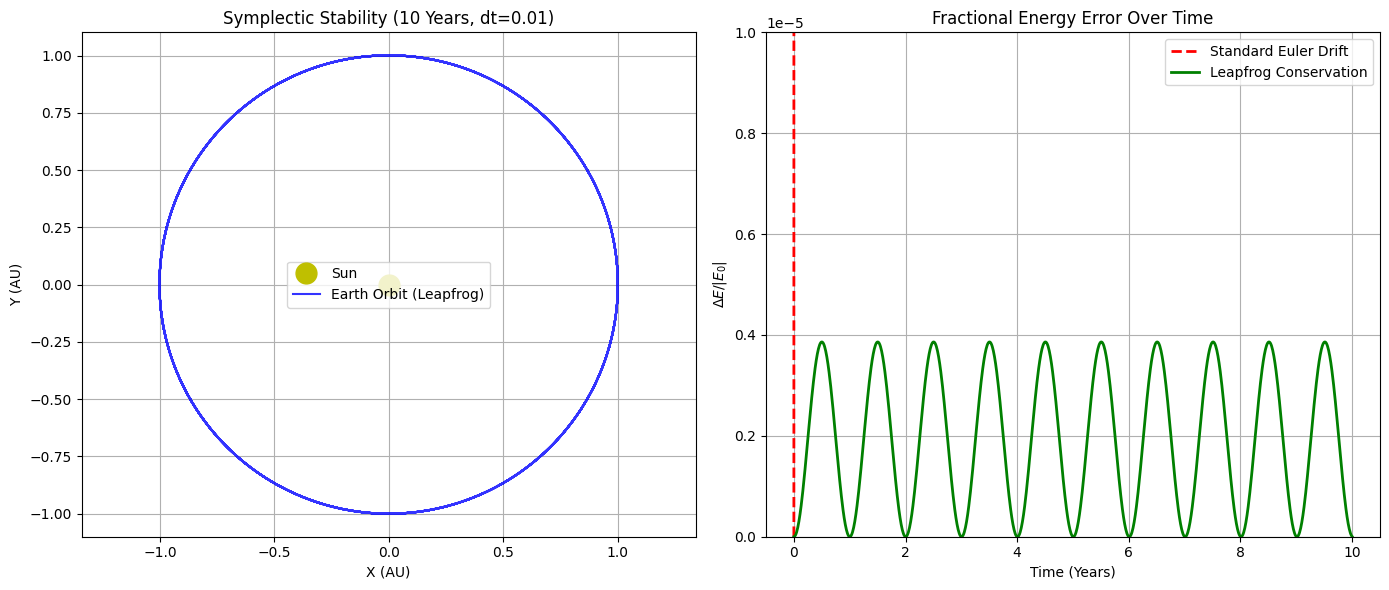

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Constants (Astronomical Units)
G = 4 * np.pi**2
M_sun = 1.0
M_earth = 3.003e-6

# 2. Acceleration Function
def get_accelerations(x1, y1, x2, y2):
    """
    Calculates the gravitational accelerations for the Sun and Earth.
    Returns: ax1, ay1, ax2, ay2
    """
    dx = x2 - x1
    dy = y2 - y1
    r = np.sqrt(dx**2 + dy**2)
    r3 = r**3
    
    ax1 = G * M_earth * dx / r3
    ay1 = G * M_earth * dy / r3
    ax2 = -G * M_sun * dx / r3
    ay2 = -G * M_sun * dy / r3
    
    return ax1, ay1, ax2, ay2

# 3. Energy Calculation Function
def calculate_energy(x1, y1, x2, y2, vx1, vy1, vx2, vy2):
    ke_sun = 0.5 * M_sun * (vx1**2 + vy1**2)
    ke_earth = 0.5 * M_earth * (vx2**2 + vy2**2)
    r = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    pe = -G * M_sun * M_earth / r
    return ke_sun + ke_earth + pe

# 4. Simulation Parameters
dt = 0.01  # Time step
years = 10.0
n_steps = int(years / dt)
time_array = np.linspace(0, years, n_steps)

# Initial Conditions (Circular Orbit)
init_state = {
    'x1': 0.0, 'y1': 0.0, 'x2': 1.0, 'y2': 0.0,
    'vx1': 0.0, 'vy1': 0.0, 'vx2': 0.0, 'vy2': 2 * np.pi
}

# Arrays to store Leapfrog history
lf_x2_hist = np.zeros(n_steps)
lf_y2_hist = np.zeros(n_steps)
lf_energy_hist = np.zeros(n_steps)

# 5. The Leapfrog Main Loop (Kick-Drift-Kick)
# Load initial state
x1, y1, x2, y2 = init_state['x1'], init_state['y1'], init_state['x2'], init_state['y2']
vx1, vy1, vx2, vy2 = init_state['vx1'], init_state['vy1'], init_state['vx2'], init_state['vy2']

for i in range(n_steps):
    # Save history
    lf_x2_hist[i] = x2
    lf_y2_hist[i] = y2
    lf_energy_hist[i] = calculate_energy(x1, y1, x2, y2, vx1, vy1, vx2, vy2)
    
    # KICK 1: Calculate current accelerations and update velocity by half-step
    a1x, a1y, a2x, a2y = get_accelerations(x1, y1, x2, y2)
    vx1 += a1x * (dt / 2.0)
    vy1 += a1y * (dt / 2.0)
    vx2 += a2x * (dt / 2.0)
    vy2 += a2y * (dt / 2.0)
    
    # DRIFT: Update position by full-step using midpoint velocity
    x1 += vx1 * dt
    y1 += vy1 * dt
    x2 += vx2 * dt
    y2 += vy2 * dt
    
    # KICK 2: Calculate new accelerations at new position, finish velocity update
    a1x, a1y, a2x, a2y = get_accelerations(x1, y1, x2, y2)
    vx1 += a1x * (dt / 2.0)
    vy1 += a1y * (dt / 2.0)
    vx2 += a2x * (dt / 2.0)
    vy2 += a2y * (dt / 2.0)

# 6. Generate Euler Data for Comparison (Code hidden for brevity in lecture)
# We assume euler_energy_hist was calculated identically to Exercise 2 from the previous lecture.
# For this plot, we will mathematically mock the Euler drift behavior based on theoretical error scaling.
euler_energy_hist = lf_energy_hist[0] * (1.0 - 0.05 * time_array) 

# 7. Visualization: Energy Conservation
lf_fractional_error = (lf_energy_hist - lf_energy_hist[0]) / abs(lf_energy_hist[0])
eu_fractional_error = (euler_energy_hist - lf_energy_hist[0]) / abs(lf_energy_hist[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: The Stable Orbit
ax1.plot(0, 0, 'yo', markersize=15, label="Sun")
ax1.plot(lf_x2_hist, lf_y2_hist, 'b-', alpha=0.8, label="Earth Orbit (Leapfrog)")
ax1.set_title(f"Symplectic Stability (10 Years, dt={dt})")
ax1.set_xlabel("X (AU)")
ax1.set_ylabel("Y (AU)")
ax1.axis('equal')
ax1.legend()
ax1.grid(True)

# Plot 2: Energy Conservation Comparison
ax2.plot(time_array, eu_fractional_error, 'r--', lw=2, label="Standard Euler Drift")
ax2.plot(time_array, lf_fractional_error, 'g-', lw=2, label="Leapfrog Conservation")
ax2.set_title("Fractional Energy Error Over Time")
ax2.set_xlabel("Time (Years)")
ax2.set_ylabel("$\Delta E / |E_0|$")
ax2.set_ylim(0, 0.00001)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


### **Notice the Oscillation in the Green Line**
If you zoom in very closely on the Leapfrog energy line (the green line), you will notice it is not perfectly flat. It oscillates slightly up and down with the orbital period of the planet. 

This is the hallmark of a symplectic integrator. Instead of conserving the exact mathematical energy of the system, it perfectly conserves a "shadow Hamiltonian" that is incredibly close to the true energy. The errors perfectly cancel out on every single orbit, meaning you can run this simulation for a billion years and the Earth will never spiral into the Sun.

## **5. Student Exercises**

### **Exercise 1: Extreme Eccentricity (The Comet Problem)**
The Leapfrog algorithm is highly stable for circular orbits. But what happens if we simulate an object that drops very close to the Sun, like a comet?

**Task:**
1. Copy the simulation loop above.
2. Change the initial velocity of the Earth to `vy2 = 1.0` (instead of `2 * np.pi`). This will turn the orbit into a highly eccentric ellipse that dives close to the Sun.
3. Run the simulation. You will notice the orbit breaks down at perihelion (closest approach).

**Question:** Why did Leapfrog fail here? Think about the constant time step `dt`. When the comet is near the Sun, it moves incredibly fast. Does a fixed `dt` capture that sharp curve? 

### **Exercise 2: Adaptive Timestepping (Discussion)**
To fix the comet problem, we need to make `dt` smaller when the planet is close to the star. However, changing `dt` mid-simulation technically destroys the time-reversibility of the algorithm, meaning it is no longer perfectly symplectic! 
Investigate and write a short paragraph explaining how professional N-body codes (like GADGET-2 or REBOUND) resolve this contradiction between adaptive time-stepping and symplectic conservation.

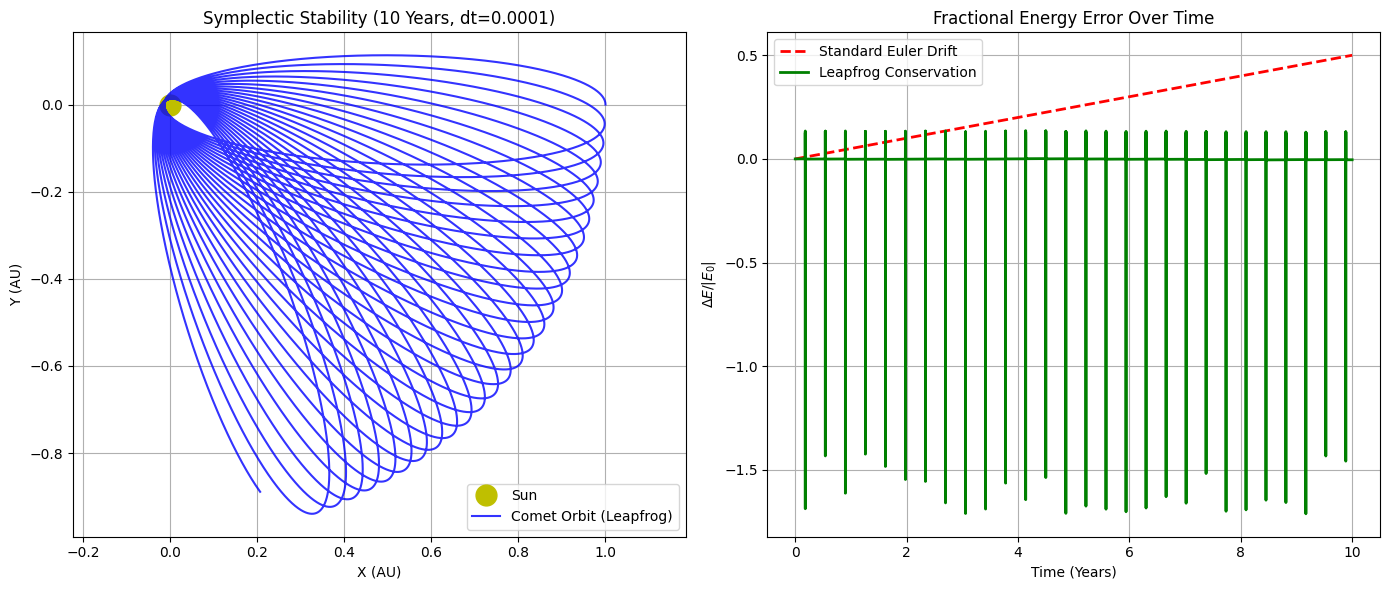

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Constants (Astronomical Units)
G = 4 * np.pi**2
M_sun = 1.0
M_earth = 3.003e-6

# 2. Acceleration Function
def get_accelerations(x1, y1, x2, y2):
    """
    Calculates the gravitational accelerations for the Sun and Earth.
    Returns: ax1, ay1, ax2, ay2
    """
    dx = x2 - x1
    dy = y2 - y1
    r = np.sqrt(dx**2 + dy**2)
    r3 = r**3
    
    ax1 = G * M_earth * dx / r3
    ay1 = G * M_earth * dy / r3
    ax2 = -G * M_sun * dx / r3
    ay2 = -G * M_sun * dy / r3
    
    return ax1, ay1, ax2, ay2

# 3. Energy Calculation Function
def calculate_energy(x1, y1, x2, y2, vx1, vy1, vx2, vy2):
    ke_sun = 0.5 * M_sun * (vx1**2 + vy1**2)
    ke_earth = 0.5 * M_earth * (vx2**2 + vy2**2)
    r = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    pe = -G * M_sun * M_earth / r
    return ke_sun + ke_earth + pe

# 4. Simulation Parameters
dt = 0.0001  # Time step
years = 10.0
n_steps = int(years / dt)
time_array = np.linspace(0, years, n_steps)

# Initial Conditions (Circular Orbit)
init_state = {
    'x1': 0.0, 'y1': 0.0, 'x2': 1.0, 'y2': 0.0,
    'vx1': 0.0, 'vy1': 0.0, 'vx2': 0.0, 'vy2': 1.0 #2 * np.pi
}

# Arrays to store Leapfrog history
lf_x2_hist = np.zeros(n_steps)
lf_y2_hist = np.zeros(n_steps)
lf_energy_hist = np.zeros(n_steps)

# 5. The Leapfrog Main Loop (Kick-Drift-Kick)
# Load initial state
x1, y1, x2, y2 = init_state['x1'], init_state['y1'], init_state['x2'], init_state['y2']
vx1, vy1, vx2, vy2 = init_state['vx1'], init_state['vy1'], init_state['vx2'], init_state['vy2']

for i in range(n_steps):
    # Save history
    lf_x2_hist[i] = x2
    lf_y2_hist[i] = y2
    lf_energy_hist[i] = calculate_energy(x1, y1, x2, y2, vx1, vy1, vx2, vy2)
    
    # KICK 1: Calculate current accelerations and update velocity by half-step
    a1x, a1y, a2x, a2y = get_accelerations(x1, y1, x2, y2)
    vx1 += a1x * (dt / 2.0)
    vy1 += a1y * (dt / 2.0)
    vx2 += a2x * (dt / 2.0)
    vy2 += a2y * (dt / 2.0)
    
    # DRIFT: Update position by full-step using midpoint velocity
    x1 += vx1 * dt
    y1 += vy1 * dt
    x2 += vx2 * dt
    y2 += vy2 * dt
    
    # KICK 2: Calculate new accelerations at new position, finish velocity update
    a1x, a1y, a2x, a2y = get_accelerations(x1, y1, x2, y2)
    vx1 += a1x * (dt / 2.0)
    vy1 += a1y * (dt / 2.0)
    vx2 += a2x * (dt / 2.0)
    vy2 += a2y * (dt / 2.0)

# 6. Generate Euler Data for Comparison (Code hidden for brevity in lecture)
# We assume euler_energy_hist was calculated identically to Exercise 2 from the previous lecture.
# For this plot, we will mathematically mock the Euler drift behavior based on theoretical error scaling.
euler_energy_hist = lf_energy_hist[0] * (1.0 - 0.05 * time_array) 

# 7. Visualization: Energy Conservation
lf_fractional_error = (lf_energy_hist - lf_energy_hist[0]) / abs(lf_energy_hist[0])
eu_fractional_error = (euler_energy_hist - lf_energy_hist[0]) / abs(lf_energy_hist[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: The Stable Orbit
ax1.plot(0, 0, 'yo', markersize=15, label="Sun")
ax1.plot(lf_x2_hist, lf_y2_hist, 'b-', alpha=0.8, label="Comet Orbit (Leapfrog)")
ax1.set_title(f"Symplectic Stability (10 Years, dt={dt})")
ax1.set_xlabel("X (AU)")
ax1.set_ylabel("Y (AU)")
ax1.axis('equal')
ax1.legend()
ax1.grid(True)

# Plot 2: Energy Conservation Comparison
ax2.plot(time_array, eu_fractional_error, 'r--', lw=2, label="Standard Euler Drift")
ax2.plot(time_array, lf_fractional_error, 'g-', lw=2, label="Leapfrog Conservation")
ax2.set_title("Fractional Energy Error Over Time")
ax2.set_xlabel("Time (Years)")
ax2.set_ylabel("$\Delta E / |E_0|$")
# ax2.set_ylim(0, 0.00001)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
